# XGBoost Hyperparameter Tuning with Multiple Metrics

This notebook demonstrates:
- Configurable target and exposure settings
- Multiple metric evaluation
- Custom insurance metrics (model_power, fit_quality)
- Lift chart visualization
- Comprehensive model comparison
- **XGBoost native CV for hyperparameter tuning** (compatible with all versions)

## Notes on Configuration

To change the target and exposure variables, modify the `CONFIG` dictionary in `config_and_metrics.py`:

```python
CONFIG = {
    'target_col': 'cc_col',      # Change to desired target
    'exposure_col': 'ee_col',    # Change to desired exposure
    'cols_to_remove': [...]      # Update columns to remove
}
```

Available target/exposure options based on your data:
- ep_bi, ep_col
- ee_bi, ee_col
- incloss_bi, incloss_col
- cc_bi, cc_col

## Import Libraries

In [95]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
import warnings
import time
import itertools
warnings.filterwarnings('ignore')

# Import our custom functions
from config_and_metrics import (
    CONFIG,
    calculate_all_metrics,
    lift_chart_modified,
    prepare_data_for_modeling,
    compare_models
)

print("Libraries imported successfully!")
print(f"\nCurrent Configuration:")
print(f"  Target: {CONFIG['target_col']}")
print(f"  Exposure: {CONFIG['exposure_col']}")

Libraries imported successfully!

Current Configuration:
  Target: cc_col
  Exposure: ee_col


## Load Data

In [96]:
# Load the feather file
file_path = 'https://github.com/axspinnacle/cfs25/raw/refs/heads/main/data/'
file_name = 'data5.ftr'

try:
    df_ini = pd.read_feather(file_path + file_name)
    print(f"Data loaded successfully!")
    print(f"Shape: {df_ini.shape}")
    print(f"\nColumns: {list(df_ini.columns)}")
except FileNotFoundError:
    print(f"File '{file_path + file_name}' not found.")
    raise

# Make a copy to preserve original
df = df_ini.copy()

Data loaded successfully!
Shape: (100443, 66)

Columns: ['pol_eff_year', 'ep_bi', 'ep_col', 'ee_bi', 'ee_col', 'incloss_bi', 'incloss_col', 'cc_bi', 'cc_col', 'zip', 'pol_id', 'vin_id', 'credit', 'commute_flag', 'veh_count_box', 'driver_count_box', 'veh_age_box', 'coll_symb_ntile', 'limit_bi', 'ded_coll', 'DrvAge_box', 'male', 'single', 'widowed', 'Date', 'Modeled_Annual_Mileage', 'Estimated_Current_Mileage', 'Annual_Mileage_Estimate', 'Number_of_Titling_Transactions', 'Lien_Holder', 'current_ownership_personal', 'current_ownership_lease', 'current_ownership_corp_govt', 'LOO_years', 'personal_use_flag', 'rental_use_flag', 'comm_use_flag', 'fleet_use_flag', 'corp_use_flag', 'lease_flag', 'curr_owner_odo_cnt', 'all_owner_odo_cnt', 'Severe_Problem_flag', 'Branded_Title_flag', 'Branded_Title_Loss_flag', 'Severe_Accident_flag', 'Other_Severe_Problem_flag', 'Failed_Emissions_flag', 'Nonsevere_Accident_flag', 'Damage_flag', 'Collision_Repair_Facility_flag', 'Potential_Damage_flag', 'Odometer_

## Prepare Data Using Configuration

In [97]:
# Use configuration to prepare data
X, y, exposure, feature_names = prepare_data_for_modeling(df, CONFIG)

print(f"Target column: {CONFIG['target_col']}")
print(f"Exposure column: {CONFIG['exposure_col']}")
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Exposure shape: {exposure.shape}")
print(f"\nTarget distribution:")
print(y.value_counts().sort_index())

Target column: cc_col
Exposure column: ee_col

Features shape: (100443, 54)
Target shape: (100443,)
Exposure shape: (100443,)

Target distribution:
cc_col
0    98418
1     1977
2       40
3        5
4        1
6        1
8        1
Name: count, dtype: int64


## Handle Categorical Variables

In [98]:
# Handle categorical variables if any, # Handle missing values if any
categorical_columns = X.select_dtypes(include=['object', 'category']).columns
if len(categorical_columns) > 0:
    print(f"Categorical columns found: {list(categorical_columns)}")
    le = LabelEncoder() #TODO
    for col in categorical_columns:
        X[col] = le.fit_transform(X[col])
    print("Categorical variables encoded")
else:
    print("No categorical variables found")

if X.isnull().sum().sum() > 0:
    print("Filling missing values with median...")
    X = X.fillna(X.median())
    print("Missing values handled")

No categorical variables found


## Train-Test Split

**Important**: We preserve exposure data for both train and test sets for metric calculation.

In [99]:
# Split data - including exposure
X_train, X_test, y_train, y_test, exposure_train, exposure_test = train_test_split(
    X, y, exposure, test_size=0.2, random_state=42
)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"\nTraining target distribution:")
print(y_train.value_counts())

Training set shape: (80354, 54)
Test set shape: (20089, 54)

Training target distribution:
cc_col
0    78747
1     1564
2       35
3        5
6        1
4        1
8        1
Name: count, dtype: int64


## Train Baseline Model

In [115]:
# Train baseline model
print("Training baseline XGBoost model...")
model = xgb.XGBRegressor(
    n_estimators=5,
    max_depth=3,
    learning_rate=0.5,
    subsample=1,
    colsample_bytree=1,
    random_state=42
)

model.fit(X_train, y_train)
print("Baseline model training completed!")

Training baseline XGBoost model...
Baseline model training completed!


## Evaluate Baseline Model with Multiple Metrics

In [116]:
# Make predictions, # Clculate all metrics

y_pred = model.predict(X_test)
original_metrics = calculate_all_metrics(y_test, y_pred, exposure_test)

print("=== Baseline Model Performance ===")
for metric, value in original_metrics.items():
    print(f"{metric}: {value:.4f}")

=== Baseline Model Performance ===
RMSE: 0.1451
MAE: 0.0408
R2: 0.0021
Model_Power: 0.2843
Fit_Quality: 0.8825


## Hyperparameter Tuning with XGBoost Native CV

We'll use XGBoost's native cross-validation to optimize for RMSE while tracking all metrics.
This approach is more efficient and avoids sklearn compatibility issues.

In [102]:
# Define hyperparameter search space
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'reg_alpha': [0, 0.01, 0.1, 1, 10],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0], 
}

print("=== HYPERPARAMETER TUNING ===")
print(f"Optimizing for: RMSE using XGBoost native CV")
print(f"\nSearch space:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

total_combos = np.prod([len(v) for v in param_grid.values()])
print(f"\nTotal combinations: {total_combos:,}")
print(f"Testing 50 random combinations with 3-fold CV\n")

=== HYPERPARAMETER TUNING ===
Optimizing for: RMSE using XGBoost native CV

Search space:
  n_estimators: [100, 200, 300, 500]
  max_depth: [3, 4, 5, 6, 7, 8]
  learning_rate: [0.01, 0.05, 0.1, 0.15, 0.2]
  reg_alpha: [0, 0.01, 0.1, 1, 10]
  subsample: [0.6, 0.7, 0.8, 0.9, 1.0]

Total combinations: 3,000
Testing 50 random combinations with 3-fold CV



In [103]:
# Function to perform random hyperparameter search using XGBoost CV
def random_search_xgboost(X_train, y_train, param_grid, n_iter=50, cv=3, random_state=42):
    """
    X_train : DataFrame , Training features
    y_train : Series, Training target
    param_grid : dict, Parameter grid to search
    n_iter : int, Number of random combinations to try
    cv : int, Number of cross-validation folds
    random_state : int, Random state for reproducibility
    Returns, tuple : (best_params, best_score, results)
    """
    np.random.seed(random_state)
    # Generate random parameter combinations,     # Prepare DMatrix
    param_combinations = []
    for _ in range(n_iter):
        params = {key: np.random.choice(values) for key, values in param_grid.items()}
        param_combinations.append(params)
    

    dtrain = xgb.DMatrix(X_train, label=y_train)
    
    best_score = float('inf')
    best_params = None
    results = []
    
    print("Starting hyperparameter search...")
    for i, params in enumerate(param_combinations, 1):
        xgb_params = {
            'objective': 'reg:squarederror',
            'eval_metric': 'rmse',
            'max_depth': params['max_depth'],
            'learning_rate': params['learning_rate'],
            'subsample': params['subsample'],
            'reg_alpha': params['reg_alpha'],
            'seed': random_state
        }
        
        cv_results = xgb.cv(
            xgb_params,
            dtrain,
            num_boost_round=params['n_estimators'],
            nfold=cv,
            metrics='rmse',
            early_stopping_rounds=10,
            verbose_eval=False,
            seed=random_state
        )
        
        score = cv_results['test-rmse-mean'].min()
        
        results.append({
            'params': params.copy(),
            'score': score
        })
        
        if score < best_score:
            best_score = score
            best_params = params.copy()
        
        if i % 10 == 0:
            print(f"Completed {i}/{n_iter} combinations (Best RMSE so far: {best_score:.4f})")
    
    return best_params, best_score, results

start_time = time.time()

best_params, best_cv_score, search_results = random_search_xgboost(
    X_train, y_train, param_grid, n_iter=50, cv=3, random_state=42
)

elapsed_time = time.time() - start_time
print(f"\nHyperparameter tuning completed in {elapsed_time/60:.2f} minutes")

Starting hyperparameter search...
Completed 10/50 combinations (Best RMSE so far: 0.1506)
Completed 20/50 combinations (Best RMSE so far: 0.1506)
Completed 30/50 combinations (Best RMSE so far: 0.1506)
Completed 40/50 combinations (Best RMSE so far: 0.1506)
Completed 50/50 combinations (Best RMSE so far: 0.1506)

Hyperparameter tuning completed in 0.82 minutes


## Best Hyperparameters

In [104]:
# Display best parameters
print("=== BEST HYPERPARAMETERS ===")
print(f"Best CV RMSE: {best_cv_score:.4f}")
print("\nBest parameters:")
for param, value in sorted(best_params.items()):
    print(f"  {param}: {value}")

# Train final model with best parameters
print("\nTraining final model with best parameters...")
best_model = xgb.XGBRegressor(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    subsample=best_params['subsample'],
    reg_alpha=best_params['reg_alpha'],
    random_state=42
)

best_model.fit(X_train, y_train)
print("Training completed!")

=== BEST HYPERPARAMETERS ===
Best CV RMSE: 0.1506

Best parameters:
  learning_rate: 0.1
  max_depth: 3
  n_estimators: 300
  reg_alpha: 10.0
  subsample: 0.7

Training final model with best parameters...
Training completed!


## Evaluate Tuned Model with All Metrics

In [105]:
# Make predictions with tuned model
y_pred_tuned = best_model.predict(X_test)

# Calculate all metrics for tuned model
tuned_metrics = calculate_all_metrics(y_test, y_pred_tuned, exposure_test)

print("=== Tuned Model Performance ===")
for metric, value in tuned_metrics.items():
    print(f"{metric}: {value:.4f}")

=== Tuned Model Performance ===
RMSE: 0.1450
MAE: 0.0407
R2: 0.0036
Model_Power: 0.4323
Fit_Quality: 0.8080


## Comprehensive Model Comparison

In [106]:
# Compare models
comparison_df = compare_models(original_metrics, tuned_metrics)

print("=== MODEL COMPARISON ===")
print(comparison_df.to_string(index=False))

# Determine if model improved
rmse_improved = tuned_metrics['RMSE'] < original_metrics['RMSE']
print(f"\n{'✅ SUCCESS' if rmse_improved else '⚠️  WARNING'}: "
      f"Tuned model {'improved' if rmse_improved else 'did not improve'} RMSE")

=== MODEL COMPARISON ===
     Metric  Original    Tuned  Improvement
       RMSE  0.145129 0.145030    -0.068414
        MAE  0.040831 0.040689    -0.348351
         R2  0.002282 0.003647    59.796803
Model_Power  0.341443 0.432305   -26.611233
Fit_Quality  0.868273 0.807972    -6.944928

✅ SUCCESS: Tuned model improved RMSE


## Lift Chart Visualization - Baseline Model

=== BASELINE MODEL LIFT CHART ===


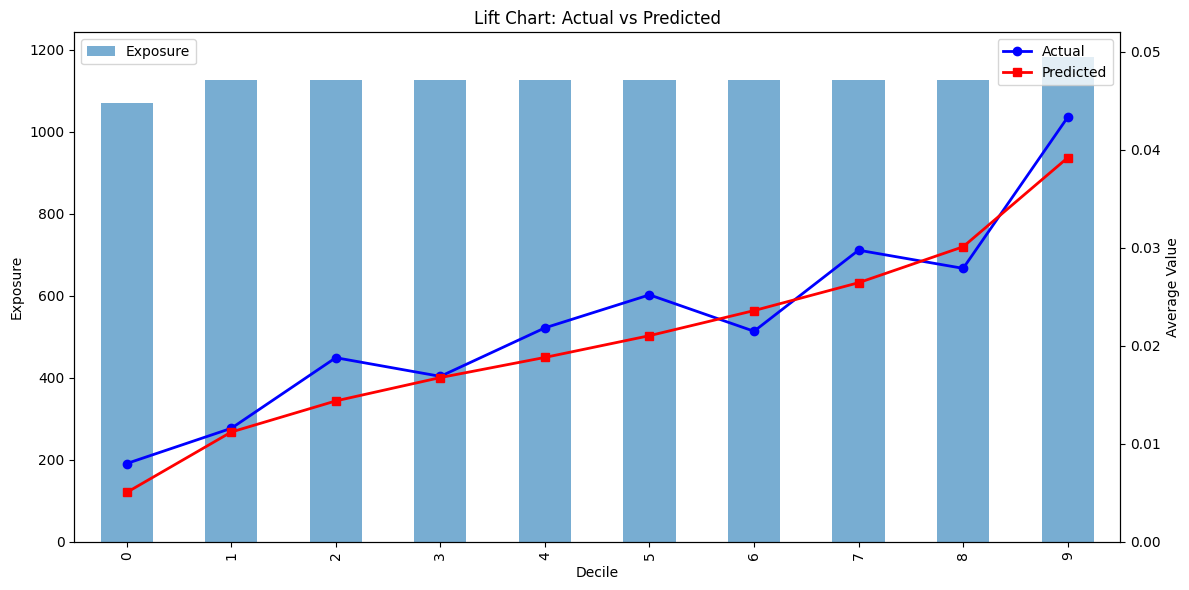


Lift Chart Summary:
 decile    exposure      act     pred
    1.0 1070.199027 0.007991 0.005043
    2.0 1126.394618 0.011585 0.011207
    3.0 1126.680964 0.018794 0.014382
    4.0 1126.940407 0.016889 0.016765
    5.0 1126.763268 0.021838 0.018821
    6.0 1126.824463 0.025208 0.021041
    7.0 1126.784490 0.021491 0.023600
    8.0 1126.568553 0.029765 0.026446
    9.0 1126.608489 0.027910 0.030115
   10.0 1183.364122 0.043331 0.039202


In [107]:
# Prepare data for lift chart - baseline model
test_results_baseline = pd.DataFrame({
    'act': y_test,
    'pred': y_pred,
    'exposure': exposure_test
})
test_results_baseline['act_weighted'] = test_results_baseline['act'] * test_results_baseline['exposure']
test_results_baseline['pred_weighted'] = test_results_baseline['pred'] * test_results_baseline['exposure']

print("=== BASELINE MODEL LIFT CHART ===")
lift_chart_modified(test_results_baseline, 'exposure', bins=10, print_table=True)

## Lift Chart Visualization - Tuned Model

=== TUNED MODEL LIFT CHART ===


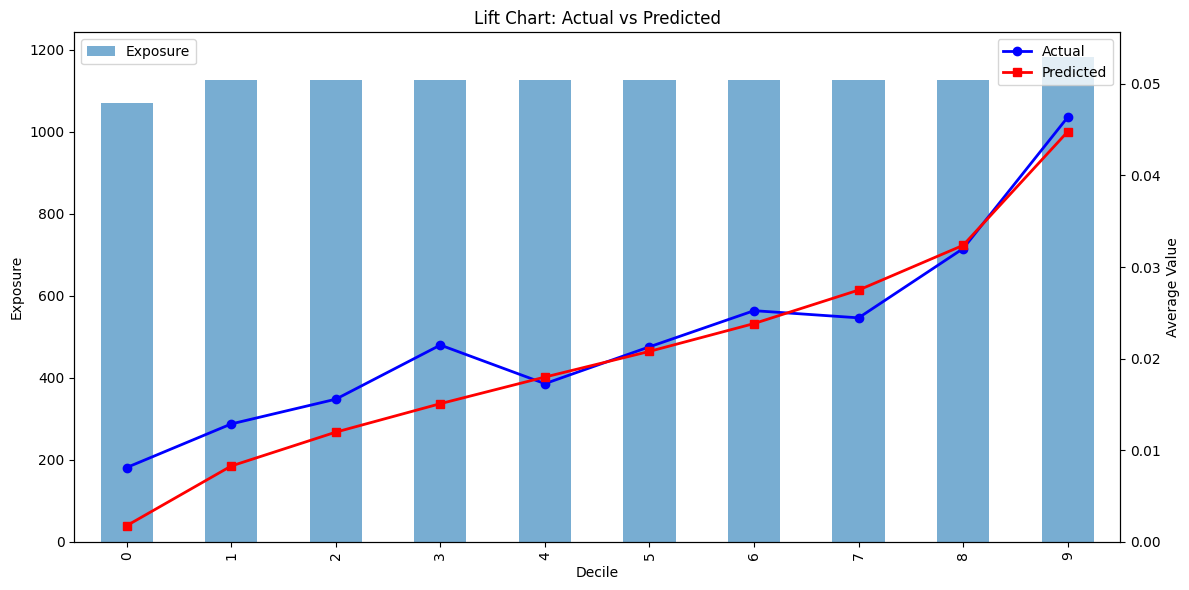


Lift Chart Summary:
 decile    exposure      act     pred
    1.0 1070.250041 0.008114 0.001766
    2.0 1126.601407 0.012871 0.008279
    3.0 1126.183449 0.015573 0.011976
    4.0 1127.227465 0.021482 0.015085
    5.0 1126.735295 0.017267 0.017988
    6.0 1126.516708 0.021291 0.020793
    7.0 1127.006595 0.025236 0.023829
    8.0 1126.446725 0.024453 0.027484
    9.0 1126.800741 0.032015 0.032371
   10.0 1183.359975 0.046349 0.044777


In [108]:
# Prepare data for lift chart - tuned model
test_results_tuned = pd.DataFrame({
    'act': y_test,
    'pred': y_pred_tuned,
    'exposure': exposure_test
})
test_results_tuned['act_weighted'] = test_results_tuned['act'] * test_results_tuned['exposure']
test_results_tuned['pred_weighted'] = test_results_tuned['pred'] * test_results_tuned['exposure']

print("=== TUNED MODEL LIFT CHART ===")
lift_chart_modified(test_results_tuned, 'exposure', bins=10, print_table=True)

## Feature Importance Comparison

In [109]:
# Compare feature importance
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance_original': model.feature_importances_,
    'importance_tuned': best_model.feature_importances_
}).sort_values('importance_tuned', ascending=False)

feature_importance_df['change'] = (
    feature_importance_df['importance_tuned'] - 
    feature_importance_df['importance_original']
)

print("=== TOP 10 FEATURES (TUNED MODEL) ===")
print(feature_importance_df.head(10).to_string(index=False))

print("\n=== BIGGEST INCREASES IN IMPORTANCE ===")
print(feature_importance_df.nlargest(5, 'change')[['feature', 'importance_original', 'importance_tuned', 'change']].to_string(index=False))

print("\n=== BIGGEST DECREASES IN IMPORTANCE ===")
print(feature_importance_df.nsmallest(5, 'change')[['feature', 'importance_original', 'importance_tuned', 'change']].to_string(index=False))

=== TOP 10 FEATURES (TUNED MODEL) ===
                                 feature  importance_original  importance_tuned    change
                                  credit             0.080866          0.049411 -0.031455
                             veh_age_box             0.115518          0.046236 -0.069282
                           veh_count_box             0.051215          0.039477 -0.011738
       Annual_Mileage_Estimate_null_flag             0.000000          0.038731  0.038731
                               LOO_years             0.078385          0.036613 -0.041771
                       personal_use_flag             0.000000          0.033666  0.033666
                                 widowed             0.025345          0.031229  0.005884
                       pop_density_ntile             0.061291          0.029756 -0.031535
                                ded_coll             0.048316          0.029703 -0.018613
Number_of_Titling_Transactions_null_flag             0.000000 

## Hyperparameter Search Analysis

In [110]:
# Analyze search results
results_df = pd.DataFrame([
    {'RMSE': r['score'], **r['params']} 
    for r in search_results
]).sort_values('RMSE')

print("=== TOP 10 PARAMETER COMBINATIONS ===")
print(results_df.head(10).to_string(index=False))

print("\n=== BOTTOM 5 PARAMETER COMBINATIONS ===")
print(results_df.tail(5).to_string(index=False))

=== TOP 10 PARAMETER COMBINATIONS ===
    RMSE  n_estimators  max_depth  learning_rate  reg_alpha  subsample
0.150570           300          3           0.10       10.0        0.7
0.150591           100          6           0.05       10.0        0.9
0.150594           300          8           0.05       10.0        0.9
0.150602           300          4           0.01        1.0        0.6
0.150603           200          7           0.01       10.0        0.9
0.150612           500          7           0.01       10.0        1.0
0.150614           500          5           0.01        1.0        0.6
0.150614           500          4           0.01        1.0        0.9
0.150616           300          6           0.15       10.0        0.8
0.150617           300          4           0.05        1.0        0.7

=== BOTTOM 5 PARAMETER COMBINATIONS ===
    RMSE  n_estimators  max_depth  learning_rate  reg_alpha  subsample
0.150804           100          8           0.20        1.0        0.

## Comprehensive Model Comparison

Side-by-side comparison of hyperparameters and all metrics.

In [111]:
# Baseline model hyperparameters
baseline_params = {
    'n_estimators': 100,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'reg_alpha': 0
}

# === TABLE 1: HYPERPARAMETERS COMPARISON ===
hyperparam_data = []
for param in sorted(baseline_params.keys()):
    hyperparam_data.append({
        'Hyperparameter': param,
        'Baseline Model': baseline_params[param],
        'Tuned Model': best_params[param],
        'Change': f"{best_params[param] - baseline_params[param]:+g}"
    })

hyperparam_df = pd.DataFrame(hyperparam_data)

# === TABLE 2: METRICS COMPARISON ===
metrics_data = []
for metric in original_metrics.keys():
    baseline_val = original_metrics[metric]
    tuned_val = tuned_metrics[metric]
    
    # Calculate improvement percentage
    # Note: For RMSE, MAE, Model_Power - lower is better
    # For R2, Fit_Quality - higher is better
    if metric in ['RMSE', 'MAE', 'Model_Power']:
        pct_change = ((baseline_val - tuned_val) / abs(baseline_val)) * 100
        improved = tuned_val < baseline_val
    else:
        pct_change = ((tuned_val - baseline_val) / abs(baseline_val)) * 100
        improved = tuned_val > baseline_val
    
    metrics_data.append({
        'Metric': metric,
        'Baseline Model': f"{baseline_val:.4f}",
        'Tuned Model': f"{tuned_val:.4f}",
        'Change (%)': f"{pct_change:+.2f}%",
        'Status': '✅ Improved' if improved else '⚠️  Declined'
    })

metrics_df = pd.DataFrame(metrics_data)

# Display both tables
print("=" * 90)
print("COMPREHENSIVE MODEL COMPARISON")
print("=" * 90)
print(f"\nDataset: {X.shape[0]:,} samples, {X.shape[1]} features")
print(f"Target: {CONFIG['target_col']} | Exposure: {CONFIG['exposure_col']}")

print("\n" + "=" * 90)
print("TABLE 1: HYPERPARAMETERS COMPARISON")
print("=" * 90)
print(hyperparam_df.to_string(index=False))



COMPREHENSIVE MODEL COMPARISON

Dataset: 100,443 samples, 54 features
Target: cc_col | Exposure: ee_col

TABLE 1: HYPERPARAMETERS COMPARISON
Hyperparameter  Baseline Model  Tuned Model Change
 learning_rate             0.1          0.1     +0
     max_depth             6.0          3.0     -3
  n_estimators           100.0        300.0   +200
     reg_alpha             0.0         10.0    +10
     subsample             0.8          0.7   -0.1


In [112]:
print("\n" + "=" * 90)
print("TABLE 2: METRICS COMPARISON")
print("=" * 90)
print(metrics_df.to_string(index=False))

print("\n" + "=" * 90)
print("Notes:")
print("  • Lower is better: RMSE, MAE, Model_Power")
print("  • Higher is better: R2, Fit_Quality")
print("  • Change (%) shows improvement direction for each metric")
print("=" * 90)


TABLE 2: METRICS COMPARISON
     Metric Baseline Model Tuned Model Change (%)       Status
       RMSE         0.1451      0.1450     +0.07%   ✅ Improved
        MAE         0.0408      0.0407     +0.35%   ✅ Improved
         R2         0.0023      0.0036    +59.80%   ✅ Improved
Model_Power         0.3414      0.4323    -26.61% ⚠️  Declined
Fit_Quality         0.8683      0.8080     -6.94% ⚠️  Declined

Notes:
  • Lower is better: RMSE, MAE, Model_Power
  • Higher is better: R2, Fit_Quality
  • Change (%) shows improvement direction for each metric


## Final Summary

In [113]:
print("=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)

print(f"\nDataset: {X.shape[0]:,} samples, {X.shape[1]} features")
print(f"Target: {CONFIG['target_col']}")
print(f"Exposure: {CONFIG['exposure_col']}")

print("\n" + "=" * 70)
print("TOP 5 FEATURES")
print("=" * 70)
for i, (_, row) in enumerate(feature_importance_df.head(5).iterrows(), 1):
    print(f"{i}. {row['feature']}: {row['importance_tuned']:.4f}")

# Overall improvement assessment
rmse_improved = tuned_metrics['RMSE'] < original_metrics['RMSE']
quality_improved = tuned_metrics['Fit_Quality'] > original_metrics['Fit_Quality']
power_improved = tuned_metrics['Model_Power'] < original_metrics['Model_Power']

improvements = sum([rmse_improved, quality_improved, power_improved])

print("\n" + "=" * 70)
print("OVERALL ASSESSMENT")
print("=" * 70)
print(f"✅ RMSE: {'Improved' if rmse_improved else 'No improvement'}")
print(f"✅ Fit Quality: {'Improved' if quality_improved else 'No improvement'}")
print(f"✅ Model Power: {'Improved' if power_improved else 'No improvement'}")
print(f"\n{'🎉 SUCCESS' if improvements >= 2 else '⚠️  MIXED RESULTS'}: "
      f"Tuned model improved {improvements}/3 key metrics")

print("\n✅ Analysis complete! The tuned model is available as 'best_model'.")

FINAL MODEL SUMMARY

Dataset: 100,443 samples, 54 features
Target: cc_col
Exposure: ee_col

TOP 5 FEATURES
1. credit: 0.0494
2. veh_age_box: 0.0462
3. veh_count_box: 0.0395
4. Annual_Mileage_Estimate_null_flag: 0.0387
5. LOO_years: 0.0366

OVERALL ASSESSMENT
✅ RMSE: Improved
✅ Fit Quality: No improvement
✅ Model Power: No improvement

⚠️  MIXED RESULTS: Tuned model improved 1/3 key metrics

✅ Analysis complete! The tuned model is available as 'best_model'.


## Additional Analysis: Custom Metric Functions

You can also call the metric functions individually for more detailed analysis:

In [114]:
# Example: Calculate custom metrics for specific predictions
from config_and_metrics import model_metrics

# Prepare data
custom_eval = pd.DataFrame({
    'act': y_test,
    'pred': y_pred_tuned,
    'exposure': exposure_test
})
custom_eval['act_weighted'] = custom_eval['act'] * custom_eval['exposure']
custom_eval['pred_weighted'] = custom_eval['pred'] * custom_eval['exposure']

# Calculate metrics
power, quality = model_metrics(
    custom_eval,
    'act_weighted',
    'pred_weighted',
    'exposure'
)

print("=== CUSTOM METRIC CALCULATION ===")
print(f"Model Power: {power:.4f}")
print(f"Fit Quality: {quality:.4f}")
print("\nNote: Lower Model Power = Better (less deviation from unity)")
print("      Higher Fit Quality = Better (predictions closer to actuals)")

=== CUSTOM METRIC CALCULATION ===
Model Power: 0.4323
Fit Quality: 0.8080

Note: Lower Model Power = Better (less deviation from unity)
      Higher Fit Quality = Better (predictions closer to actuals)
